In [2]:
!pip install normflows lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.3/65.3 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 39.6 MB/s eta 0:00:00
  Created wheel for normflows: filename=normflows-1.7.3-py2.py3-none-any.whl size=87247 sha256=c96413d58c07c4ce8e4cb817d269368dcc2e4ac7ee859b62c104affb45cf0081
  Stored in directory: /root/.cache/pip/wheels/f7/b4/37/a3acc21799a058d6fe15127321dcdf99826f438bb591accafa
Successfully built normflows


# Generative models: VAE + Diffusion = Latent Diffusion.

The goal of this notebook is to introduce the students to VAE and Diffusion training. To do so, we will consider the Fashion MNIST dataset.

## Dataset Loading and exploration.

The next cells define simple data loading procedures and visualization.

In [4]:
%load_ext tensorboard
from torchvision.datasets import FashionMNIST
from torchvision.transforms import ToTensor, Compose, Normalize, RandomRotation, RandomHorizontalFlip, Pad
import matplotlib.pyplot as plt
import tqdm
from torch import randint, jit, nn, distributions, chunk, ones, ones_like, zeros, zeros_like, Tensor, optim, linalg, randn, randn_like, no_grad, concatenate, linspace
from tqdm import tqdm
import lightning as L
from typing import Union, Dict, Any, Tuple, Callable
import itertools
import math
from torch.utils.data import DataLoader, SubsetRandomSampler, TensorDataset, StackDataset
from diffusers import UNet2DModel
import normflows as nf


The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [7]:
root_path = "data"
download = True
transform = Compose(
    [
        ToTensor(),
        jit.script(
            nn.Sequential(
                # RandomHorizontalFlip(),
                # RandomRotation(45, fill=0),
                Pad((2, 2), fill=0)
            )
        ),
    ]
)
train_dataset = FashionMNIST(root_path, transform=transform, download=download)
transform_test = Compose(
    [
        ToTensor(),
        Pad((2, 2), fill=0)
    ]
)
test_dataset = FashionMNIST(root_path, transform=transform_test, train=False, download=download)
indices_train = list(range(0, 50_000))
indices_cv = list(range(50_000, 60_000))

train_sampler = SubsetRandomSampler(indices_train)
cv_sampler = SubsetRandomSampler(indices_cv)

###
# !!!!ATTENTION!!!!!You might want to adapt this to your machine
batch_size = 512
num_workers = 4
###
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=train_sampler,
    num_workers=num_workers,
)
cv_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    sampler=cv_sampler,
    num_workers=num_workers,
)

n_channels, height, width = train_dataset[0][0].shape
train_size = 50_000
cv_size = 10_000
print(f"Total of {train_size} images of shape {(n_channels, height, width)}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.8MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 206kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.6MB/s]

Total of 50000 images of shape (1, 32, 32)



/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


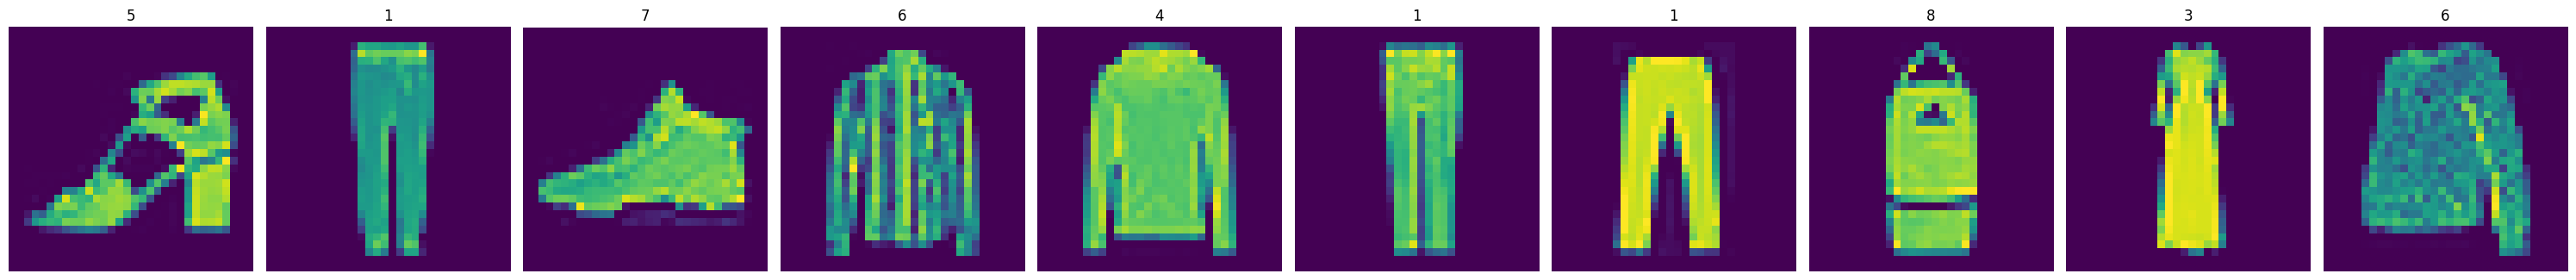

In [8]:
n_display = 10
fig, axes = plt.subplots(1, n_display, figsize=(3*n_display, 3.5))
batch_dt = next(iter(train_loader))
for i, ax in zip(randint(0, batch_size, (n_display,)), axes):
    ax.imshow(batch_dt[0][i, 0], vmin=0, vmax=1)
    ax.set_title(batch_dt[1][i].item())
    ax.set_axis_off()
fig.tight_layout()
fig.show()

## VAE Training

We now focus on the training of the VAE. To do so, we will rely on [Pytorch Lightning](https://lightning.ai/docs/pytorch/stable/starter/introduction.html). Lightning is a really handy tool. It avoids writing boilerplate code and has several functions that allow to scale your code.
It main object is the LightningModule.

### Q1.1:
In the cell below, complete both the code for the method Elbo in the AbstractVAE class.
### Q1.2
In the cell below, complete the class GaussGaussVAE in order to implement a model where both $p(z |x)$, $p(x|z)$ and $p(z)$ are Gaussians.

In [ ]:
def make_image_independent_gaussian(mean, logvar, img_dims=(1, 2, 3)):
    dist = distributions.Normal(
        loc=mean, scale=(0.5 * logvar).exp(), validate_args=False
    )
    dist = distributions.Independent(dist, 3, validate_args=False)
    return dist


class AbstractPrior(object):
    def rsample(shape):
        raise NotImplementedError("You should pass a Prior")


class AbstractVAE(L.LightningModule):
    def __init__(
        self,
        encoder_class: nn.Module,
        decoder_class: nn.Module,
        encoder_params: Dict[str, Any],
        decoder_params: Dict[str, Any],
        optim_config,
        n_images_to_log: int = 4,
        **kwargs,
    ):
        super().__init__()
        self.prior = AbstractPrior()
        self.optim_config = optim_config
        self.encoder = encoder_class(**encoder_params)
        self.decoder = decoder_class(**decoder_params)
        self.n_images_to_log = n_images_to_log

    def encode(self, x: Tensor) -> distributions.Distribution:
        """
        The goal of this function is to return the latent distribution from a given data sample $x$ as a pytorch distribution ! In probabilistic notation, p(z |x).
        """
        raise NotImplementedError("Encode not implemented")

    def decode(self, latents: Tensor) -> distributions.Distribution:
        """
        The goal of this function is to return the distribution of a data sample given a latent code $z$ as a pytorch distribution. In probabilistic notation, p(x | z)
        """
        raise NotImplementedError("Decoder not implemented")

    def prior_kl(
        self, latent_distribution: distributions.Distribution
    ) -> Tensor:
        """
        The goal of this function is to calculate the Kullback leibler between the prior and the latent distribution for a given data sample $x$. In probabilistic notation, it should output $D_{KL}(prior || p(.|x)).
        """
        raise NotImplementedError("Prior kl not implemented")

    def r_sample(self, sample_shape: Tuple[int]) -> Tensor:
        """
        The goal of this function is to return a reparametrized sample for the whole model.
        """
        raise NotImplementedError("Sampling from model not implemented")

    def elbo(self, images: torch.Tensor):
        """
        :images: Torch tensor of size (n_batches, 1, 32, 32)
        """
        #### YOUR CODE HERE.

        return (
            elbo,
            likelihood_observation,
            kl_prior,
            latent_distribution,
            data_given_latent,
        )

    def training_step(self, batch, batch_idx):
        images = batch[0].float()
        elbo, lk, kl = self.elbo(images)[:3]

        self.log("train/lk", lk, prog_bar=True)
        self.log("train/kl", kl, prog_bar=True)
        return -elbo

    def validation_step(self, batch, batch_idx):
        metrics = {}
        images = batch[0].float()
        elbo, lk, kl, latent_distribution, data_distribution = self.elbo(images)
        fake_images = data_distribution.rsample((1,))[0]

        metrics["val/elbo"] = elbo
        metrics["val/lk"] = lk
        metrics["val/kl"] = kl
        metrics["val/uRMSE"] = linalg.vector_norm(
            0.5 * (fake_images - images)
        ).mean() / (images[0].numel() ** 0.5)

        for k, v in metrics.items():
            self.log(k, v, on_step=False, on_epoch=True, prog_bar=False, sync_dist=True)
        if batch_idx == 0:
            self.reconstructions_per_class = {
                i: fake_images[i] for i in range(self.n_images_to_log)
            }
            self.original_per_class = {
                i: images[i] for i in range(self.n_images_to_log)
            }

    def on_before_optimizer_step(self, optimizer):
        norms = {
            **{
                f"encoder/grad/{k}": v.item()
                for k, v in L.pytorch.utilities.grad_norm(
                    self.encoder, norm_type=2
                ).items()
            },
            **{
                f"decoder/grad/{k}": v.item()
                for k, v in L.pytorch.utilities.grad_norm(
                    self.decoder, norm_type=2
                ).items()
            },
        }

        self.log_dict(norms)

    def on_validation_epoch_end(self):
        for cl in self.original_per_class:
            self.logger.experiment.add_image(
                f"{cl}/rec_image",
                self.reconstructions_per_class[cl],
                self.current_epoch,
            )
            self.logger.experiment.add_image(
                f"{cl}/or_image", self.original_per_class[cl], self.current_epoch
            )

        self.original_per_class.clear()
        self.reconstructions_per_class.clear()
        z = self.prior.sample((8,))[:, 0]
        prior_gen_images = self.decode(z).sample((1,))[0]
        for i, img in enumerate(prior_gen_images):
            self.logger.experiment.add_image(f"gen_image/{i}", img, self.current_epoch)

    def configure_optimizers(self):
        if self.optim_config["optimizer"]["type"] == "Adam":
            optimizer = optim.Adam(
                itertools.chain(self.encoder.parameters(), self.decoder.parameters()),
                self.optim_config["optimizer"]["base_learning_rate"],
            )
        else:
            raise NotImplementedError("Only Adam implemented")
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer,
                    factor=self.optim_config["lr_schedule"]["factor"],
                    mode=self.optim_config["lr_schedule"]["metric_mode"],
                ),
                "monitor": self.optim_config["lr_schedule"]["metric_to_track"],
                "frequency": self.optim_config["lr_schedule"]["frequency"],
            },
        }


class GaussGaussVAE(AbstractVAE):
    def __init__(
        self, prior_mean, prior_logvar, scale_max,  **kwargs
    ):

        super().__init__(**kwargs)
        self.dec_scale_max = scale_max
        self.prior = None
        self.prior_mean = prior_mean
        self.prior_logvar = prior_logvar

        self.save_hyperparameters(
            ignore=["encoder_class", "decoder_class", "prior_mean", "prior_logvar"]
        )

    def encode(self, x):
        #### YOUR CODE HERE
        return None

    def decode(self, latents):
        #### YOUR CODE HERE
        return None

    def prior_kl(self, latent_distribution):
        ### YOUR CODE HERE
        return None

    def rsample(self, sample_shape: Tuple[int]) -> Tensor:
        latent_samples = self.prior.rsample(sample_shape).squeeze(len(sample_shape))
        data_dist = self.decode(latent_samples)
        return data_dist.rsample((1,))[0]

In [ ]:
### These are suggestions, you are welcomed to try different things.
encoder_maker = lambda : nn.Sequential(
    nn.Conv2d(1, 64, 3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(),
    nn.Conv2d(64, 64, 3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(),
    nn.AvgPool2d(2, 2),
    nn.Conv2d(64, 64, 3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(),
    nn.Conv2d(64, 64, 3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(),
    nn.AvgPool2d(2, 2),
    nn.Conv2d(64, 64, 3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(),
    nn.Conv2d(64, 64, 3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(),
    nn.AvgPool2d(2, 2),
    nn.Conv2d(64, 2, 1, stride=1, padding=0),
)
decoder_maker = lambda : nn.Sequential(
    nn.ConvTranspose2d(1, 64, 3, output_padding=1, padding=1, stride=2),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(),
    nn.Conv2d(64, 64, 3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(),
    nn.ConvTranspose2d(64, 64, 3, output_padding=1, padding=1, stride=2),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(),
    nn.Conv2d(64, 64, 3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(),
    nn.ConvTranspose2d(64, 64, 3, output_padding=1, padding=1, stride=2),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(),
    nn.Conv2d(64, 64, 3, stride=1, padding=1),
    nn.BatchNorm2d(64),
    nn.LeakyReLU(),
    nn.Conv2d(64, 1, 1, stride=1),
    nn.ReLU()
)

In [ ]:
logger = L.pytorch.loggers.TensorBoardLogger(
    save_dir="data/VAE/logs",
    name="4x4_vae",
    version=f"V1",
)
checkpoint_callback = L.pytorch.callbacks.ModelCheckpoint(
    "data/VAE/models"
)
lr_monitor = L.pytorch.callbacks.LearningRateMonitor(logging_interval="step")
trainer = L.Trainer(
    accumulate_grad_batches=1,
    callbacks=[checkpoint_callback, lr_monitor],
    logger=logger,
    max_epochs=10
)
latent_shape = (1, 4, 4)
with trainer.init_module():
    vae = GaussGaussVAE(
        encoder_class=encoder_maker,
        decoder_class=decoder_maker,
        encoder_params={},
        decoder_params={},
        prior_mean=zeros((1,) + latent_shape),
        prior_logvar=zeros((1,) + latent_shape),
        optim_config={"optimizer": {"base_learning_rate": 1e-3, "type": "Adam"}, "lr_schedule": {"factor": .5, "metric_mode": "min", "metric_to_track": "val/uRMSE", "frequency": 1}},
        variance_type="fixed",
        scale_max = 0.1
    )

In [ ]:
%tensorboard --logdir data/VAE/logs

In [ ]:
trainer.fit(
    model=vae,
    train_dataloaders=train_loader,
    val_dataloaders=cv_loader,
    ckpt_path=None
)

### Q2:

Describe the optimization procedure implemented above for the training of the VAE (No need to comment on the ELBO, rather describe at optimizer level the choices that have been made.)

## Evaluating the generative capabilities of the VAE
In this section, we will focus on the evaluation of the model.

### Q3: Write the code to generate 20 000 samples for the VAE and visualize a random subset of 10 samples.

### Q4.1: Complete the code below to calculate an integral probability (semi-) metric and calculate it for the VAE case.

In [ ]:
def calculate_ipm(samples_1, samples_2, ipf_member, max_iter, tol):
    n_1 = samples_1.shape[0]
    n_2 = samples_2.shape[0]
    train_features = concatenate([samples_1[:n_1//2], samples_2[:n_2//2]], axis=0)
    test_features = concatenate([samples_1[n_1//2:], samples_2[n_2//2:]], axis=0)
    train_labels = concatenate([zeros((n_1//2,)), ones((n_2//2,))], axis=0)
    test_labels = concatenate([zeros((n_1//2,)), ones((n_2//2,))], axis=0)

    train_dataset = StackDataset(TensorDataset(train_features), TensorDataset(train_labels))
    test_dataset = StackDataset(TensorDataset(test_features), TensorDataset(test_labels))

    train_loader = DataLoader(
        train_dataset,
        shuffle=True,
        batch_size=1_000,
        num_workers=0,
    )
    test_loader = DataLoader(
        train_dataset,
        shuffle=True,
        batch_size=1_000,
        num_workers=0,
    )
    optimizer = optim.Adam(ipf_member.parameters(), lr=1e-3, maximize=True)
    pbar = tqdm(range(max_iter))
    previous_per_epoch_loss = 1_00000
    for it in pbar:
        per_epoch_loss = []
        for (i, (features, labels)) in enumerate(train_loader):
            features, labels = features[0], labels[0]
            # Insert your code HERE
            loss=0
            per_epoch_loss.append(loss.item())
        per_epoch_loss = sum(per_epoch_loss) / len(per_epoch_loss)
        if abs(previous_per_epoch_loss - per_epoch_loss) < tol:
            break
        previous_per_epoch_loss = per_epoch_loss
        pbar.set_postfix({"ipm": per_epoch_loss})


    ipf_member.eval()
    per_epoch_loss = []
    for (i, (features, labels)) in enumerate(test_loader):
        features, labels = features[0], labels[0]
        # Insert your code HERE
        loss=0
        per_epoch_loss.append(loss.item())

    per_epoch_loss = sum(per_epoch_loss) / len(per_epoch_loss)
    return per_epoch_loss, ipf_member



In [ ]:
ipm = calculate_ipm(
    samples_1=concatenate([test_dataset[i][0][None] for i in range(len(test_dataset))], axis=0),
    samples_2=gen_samples,
    ipf_member=nn.Sequential(
        nn.Flatten(),
        nn.utils.parametrizations.weight_norm(nn.Linear(32 * 32, 1000, bias=False), "weight"),
        nn.ReLU(),
        nn.utils.parametrizations.weight_norm(nn.Linear(1000, 1000, bias=False), "weight"),
        nn.ReLU(),
        nn.utils.parametrizations.weight_norm(nn.Linear(1000, 1), "weight"),
        nn.Sigmoid(),
    ),
    max_iter=1000,
    tol=1e-4,
)[0]
print(ipm)

### Q4.2 (Bonus): Why the usage of weight normalization here can be considered a reasonable choice?

## Looking further into the latent space:

### Q5.1:  Write code to visualize the distributions of the projection of the cross validation dataset into the latent space as well as sample for the prior.

### Q5.2: Why do the generative model is so poor?

In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE

## Learning a Normalizing flow for the Latents

In this section, following the discussion above from Q5, we focus on learning a Normalizing over the Latent space.
To do so, we will again use Lightning.

### Q6: Complete the code below for the MultiLevelDenoiser class

In [ ]:
class NormalizingFlow(L.LightningModule):
    def __init__(
        self,
        normflow: nn.Module,
        optim_config,
        n_images_to_log: int = 4,
        **kwargs,
    ):
        super().__init__()
        self.optim_config = optim_config
        self.normflow = normflow
        self.n_images_to_log = n_images_to_log


    def training_step(self, batch, batch_idx):
        images = batch[0].float()
        #YOUR CODE HERE
        self.log("train/loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        images = batch[0].float()

        #YOUR CODE HERE
        self.log("validation/loss", loss.item(), on_step=False, on_epoch=True, prog_bar=False, sync_dist=True)


        if batch_idx == 0:
            self.normflow.eval()
            self.gen_images = {
                i: img.reshape(1, 4, 4)  for i, img in enumerate(self.normflow(self.normflow.q0.sample(self.n_images_to_log)))}
            self.original_images = {i: images[i] for i in range(self.n_images_to_log)}
            self.normflow.train()
    def on_before_optimizer_step(self, optimizer):

        norms = {
            **{
                f"nf/grad/{k}": v.item()
                for k, v in L.pytorch.utilities.grad_norm(
                    self.normflow, norm_type=2
                ).items()
            },
        }

        self.log_dict(norms)

    def on_validation_epoch_end(self):
        for cl in self.gen_images:
            self.logger.experiment.add_image(
                f"{cl}/gen_image",
                self.gen_images[cl],
                self.current_epoch,
            )
            self.logger.experiment.add_image(
                f"{cl}/or_image",
                self.original_images[cl],
                 self.current_epoch
            )


    def configure_optimizers(self):
        if self.optim_config["optimizer"]["type"] == "Adam":
            optimizer = optim.Adam(
                self.normflow.parameters(),
                self.optim_config["optimizer"]["base_learning_rate"],
            )
        else:
            raise NotImplementedError("Only Adam implemented")
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer,
                    factor=self.optim_config["lr_schedule"]["factor"],
                    mode=self.optim_config["lr_schedule"]["metric_mode"],
                ),
                "monitor": self.optim_config["lr_schedule"]["metric_to_track"],
                "frequency": self.optim_config["lr_schedule"]["frequency"],
            },
        }


In [ ]:
K = # number of layers of normalizing flow
latent_size = 4*4
device="cuda:0"
b = Tensor([1 if i % 2 == 0 else 0 for i in range(latent_size)]) #This define which will be x_0, which will be x_1 in the RealNVP
flows = []
for i in range(K):
    s = nf.nets.MLP([latent_size, ???, latent_size], init_zeros=True) #Config your networks for scale and translation parameters
    t = nf.nets.MLP([latent_size, ???, latent_size], init_zeros=True)
    if i % 2 == 0:
        flows += [nf.flows.MaskedAffineFlow(b, t, s)]
    else:
        flows += [nf.flows.MaskedAffineFlow(1 - b, t, s)]
    flows += [nf.flows.ActNorm(latent_size)]

# Set target and q0
q0 = nf.distributions.DiagGaussian(latent_size)

# Construct flow model
nfm = nf.NormalizingFlow(q0=q0, flows=flows, p=None)

nfm = nfm.to(device)

In [ ]:

logger = L.pytorch.loggers.TensorBoardLogger(
    save_dir="data/normflow/logs",
    name="unet",
    version=f"V1",
)
checkpoint_callback = L.pytorch.callbacks.ModelCheckpoint(
    "data/normflow/models"
)
lr_monitor = L.pytorch.callbacks.LearningRateMonitor(logging_interval="step")
trainer = L.Trainer(
    accumulate_grad_batches=1,
    callbacks=[checkpoint_callback, lr_monitor],
    logger=logger,
    log_every_n_steps=25,
    max_epochs=10
)
with trainer.init_module():
    normflow = NormalizingFlow(
        normflow=nfm,
        optim_config={"optimizer": {"base_learning_rate": 1e-3, "type": "Adam"}, "lr_schedule": {"factor": .5, "metric_mode": "min", "metric_to_track": "validation/loss", "frequency": 1}},
    )

In [ ]:
latent_train_loader = DataLoader(
    TensorDataset(latents_train),
    batch_size=1024,
    shuffle=True,
    num_workers=4,
)
latent_cv_loader = DataLoader(
    TensorDataset(latents_cv),
    batch_size=1024,
    shuffle=True,
    num_workers=4,
)

In [ ]:
%tensorboard --logdir data/normflow/logs

In [ ]:
trainer.fit(
    model=normflow,
    train_dataloaders=latent_train_loader,
    val_dataloaders=latent_cv_loader,
    ckpt_path=None
)

## Evaluating the generative model

Now that the model is trained, we focus on implementing an evaluation of its generative capabilities.
### Q7: Write a code that can sample from the full pipeline:

In [ ]:
def sample_all(
    initial_samples,
    normflow,
    vae,
):
    #YOUR CODE HERE

    return out, flow_latents

In [ ]:
n_samples_gen = 20_000
batch_size = 1000
n_steps = 50
vae.decoder.eval()
gen_latents = []
gen_samples = []
for prior_samples in tqdm(randn((n_samples_gen// batch_size, batch_size) + latent_shape)):
    with no_grad():
        batch_gen_samples, batch_gen_latents = sample_all(prior_samples.cuda(), normflow.cuda(), vae)
        gen_samples.append(batch_gen_samples.cpu())
        gen_latents.append(batch_gen_latents.cpu())

gen_samples = concatenate(gen_samples, axis=0)
gen_latents = concatenate(gen_latents, axis=0)

In [ ]:
n_display = 10
fig, axes = plt.subplots(1, n_display, figsize=(3*n_display, 3.5))
for i, ax in zip(randint(0, gen_samples.shape[0], (n_display,)), axes):
    ax.imshow(gen_samples[i, 0], vmin=0, vmax=1)
    ax.set_axis_off()
fig.tight_layout()
fig.show()

### Q8: Use the same tools as above to provide a diagnostic of the new model (NF + VAE)

### Q9: Comment the results